In [16]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression, RFE, SelectFromModel, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
import seaborn as sns


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Extração

In [17]:
df = fetch_california_housing()
display(df.target_names)
print("-"*20)
display(df.feature_names)

['MedHouseVal']

--------------------


['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

### Split

In [18]:
#X = pd.DataFrame(df.data, columns=df.feature_names)
#y = pd.Series(df.target, name=df.target_names[0])

X, y = fetch_california_housing(return_X_y=True, as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) # Stratify não entra para targets contínuas

X_train.shape


(16512, 8)

### Análise de Desempenho

In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = HistGradientBoostingRegressor(random_state=42)

base = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')

print(base.mean(), base.std())

0.8321651439002877 0.0055347036554319815


### Treinar com menos features

In [20]:
def create_pipe(k: int):
    pipe = Pipeline([
    ("sel", SelectKBest(f_regression, k=k)),
    ("model", model),
    ])

    return pipe

sel = (2,4,6)

sel_2 = cross_val_score(create_pipe(sel[0]), X_train, y_train, cv=cv, scoring='r2')
sel_4 = cross_val_score(create_pipe(sel[1]), X_train, y_train, cv=cv, scoring='r2')
sel_6 = cross_val_score(create_pipe(sel[2]), X_train, y_train, cv=cv, scoring='r2')

print(sel_2.mean(), sel_2.std())
print(sel_4.mean(), sel_4.std())
print(sel_6.mean(), sel_6.std())

0.5465476060928671 0.008435627833003993
0.6677881374851529 0.008388035499614843
0.8180586879434688 0.006921541716512432


### E se trocar o método de seleção?

In [21]:
rf = RandomForestRegressor(random_state=42, n_estimators=200)

def build_pipe(selector):
    return Pipeline([
        ("sc", StandardScaler()),
        ("sel", selector),
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ])

pipes = {
    "kbest_mi": build_pipe(SelectKBest(score_func=mutual_info_regression, k=4)),
    "rfe_lr": build_pipe(RFE(estimator=LinearRegression(), n_features_to_select=4)),
    "lasso": build_pipe(SelectFromModel(LassoCV(cv=5, random_state=42), threshold=-np.inf, max_features=4)),
    "rf": build_pipe(SelectFromModel(rf, threshold=-np.inf, max_features=4)),
}

for name, pipe in pipes.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2")
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")

pipe = pipes["kbest_mi"]

pipe.fit(X_train, y_train)
display(list(pipe[:-1].get_feature_names_out()))
print(pipe.score(X_test, y_test))

kbest_mi: mean=0.8206, std=0.0061
rfe_lr: mean=0.8160, std=0.0073
lasso: mean=0.8160, std=0.0073
rf: mean=0.8226, std=0.0065


['MedInc', 'AveRooms', 'Latitude', 'Longitude']

0.8218177956640933


### Comparação dos Modelos

In [22]:
model.fit(X_train, y_train)
r2_base_teste = model.score(X_test, y_test)

r2_sel_teste = pipe.score(X_test, y_test)

features_mantidas = list(pipe[:-1].get_feature_names_out())
features_removidas = [c for c in X.columns if c not in features_mantidas]

df_resumo = pd.DataFrame({
    'Features': [len(X.columns), len(features_mantidas)],
    'R2 CV': [round(base.mean(), 4), round(scores.mean(), 4)],
    'R2 Teste': [round(r2_base_teste, 4), round(r2_sel_teste, 4)]
}, index=['Modelo Base', 'Modelo Selecionado (k=4)'])

display(df_resumo)
print(f'Mantidas: {features_mantidas}')
print(f'Removidas: {features_removidas}')

,Features,R2 CV,R2 Teste
Modelo Base,8,0.8322,0.8347
Modelo Selecionado (k=4),4,0.8226,0.8218


Mantidas: ['MedInc', 'AveRooms', 'Latitude', 'Longitude']
Removidas: ['HouseAge', 'AveBedrms', 'Population', 'AveOccup']


### Matriz de Correlação

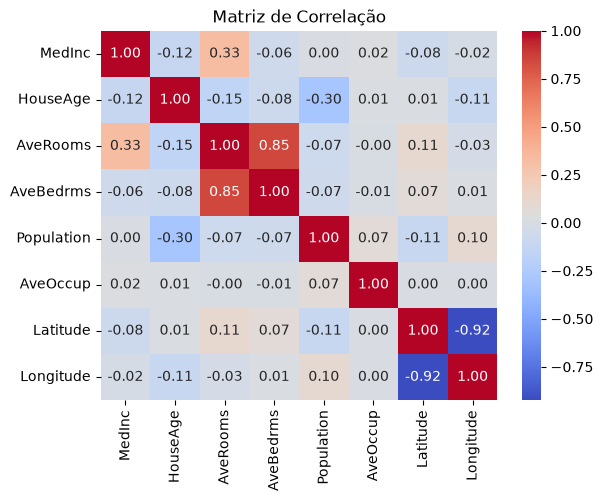

In [23]:
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

Valor negativo indica que Latitude e Longitude apresentam relações inversas entre si, ou seja, quando uma aumenta, outra diminui.

In [24]:
# Ranking do Mutual Information para ver a relevância de cada uma
mi = mutual_info_regression(X_train, y_train, random_state=42)
pd.Series(mi, index=X.columns).sort_values(ascending=False).round(4)

Longitude     0.3903
MedInc        0.3856
Latitude      0.3622
AveRooms      0.1012
AveOccup      0.0761
HouseAge      0.0359
Population    0.0266
AveBedrms     0.0253
dtype: float64

### Conclusão

- Método de seleção utilizado: `SelectKBest` com `mutual_info_regression` (k=4)

Justificativa para manter ou remover cada feature:
- MedInc (Mantida): Renda média da região. É a feature mais importante de longe, com a maior correlação e mutual information com o valor das casas.
- Latitude e Longitude (Mantidas): Localização é o fator que mais manda no preço na Califórnia (região costeira e cidades grandes são muito mais caras).
- AveRooms (Mantida): Média de cômodos. Dá uma ideia do tamanho físico do imóvel e teve bom peso no ranking.
- AveBedrms (Removida): Média de quartos. Tem correlação alta com `AveRooms`, gerando redundância.
- Population (Removida): População total do bloco. Teve a menor pontuação no mutual info e praticamente zero relação com o preço da casa.
- HouseAge (Removida): Idade do imóvel. Teve pontuação bem baixa; a localização e a renda da região pesam muito mais do que a casa ser velha ou nova.
- AveOccup (Removida): Média de moradores por casa. Não fez falta no resultado.

Conclusão:
A seleção de features foi vantajosa. Conseguimos cortar metade das features (de 8 para 4) e o R² no teste caiu apenas 0.013 (de 0.834 para 0.821), mantendo praticamente o mesmo resultado. O modelo fica mais leve, mais rápido de treinar e menos sujeito a ruídos ou dados faltando.

No modelo final, manteríamos as 4 features selecionadas (`MedInc`, `AveRooms`, `Latitude`, `Longitude`), já que elas cobrem os pontos principais: renda, tamanho e localização.